In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

label_df = GEV_clusters[["station", "cluster", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']

Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train size: (209, 165)  Test size: (70, 165)
Train class counts:
 cluster
1    102
0     91
2     16
Name: count, dtype: int64
Test class counts:
 cluster
1    34
0    31
2     5
Name: count, dtype: int64


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,
    random_state=0
)

logit_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logit),
])

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scoring = {"acc": "accuracy", "f1w": "f1_weighted"}

cv_res = cross_validate(logit_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("CV accuracy:", cv_res["test_acc"].mean(), "+/-", cv_res["test_acc"].std())
print("CV f1_weighted:", cv_res["test_f1w"].mean(), "+/-", cv_res["test_f1w"].std())
from sklearn.metrics import confusion_matrix, classification_report

logit_pipe.fit(X_train, y_train)
y_pred = logit_pipe.predict(X_test)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


CV accuracy: 0.7803716608594657 +/- 0.08895176113532526
CV f1_weighted: 0.7767713582743344 +/- 0.0874865325542624
Confusion matrix:
 [[25  6  0]
 [ 8 26  0]
 [ 3  0  2]]

Report:
               precision    recall  f1-score   support

           0       0.69      0.81      0.75        31
           1       0.81      0.76      0.79        34
           2       1.00      0.40      0.57         5

    accuracy                           0.76        70
   macro avg       0.84      0.66      0.70        70
weighted avg       0.77      0.76      0.75        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

Attribution object 1: per-cluster feature means

In [5]:
cluster_means = model_df[["cluster"]].join(X).groupby("cluster").mean()
cluster_stds  = model_df[["cluster"]].join(X).groupby("cluster").std()
cluster_counts = model_df["cluster"].value_counts().sort_index()

print("\nPer-cluster means (first 10 features):\n", cluster_means.iloc[:, :10])



Per-cluster means (first 10 features):
          u10__mean  u10__std   u10__min   u10__max  u10__median  u10__q05  \
cluster                                                                     
0         1.463204  4.679777 -14.611848  21.631088     1.584177 -6.096385   
1         1.407061  4.844429 -16.235027  22.924685     1.569321 -6.530076   
2         1.458013  4.683684 -14.850274  22.026844     1.733997 -6.247502   

         u10__q95  u10__annmax_mean  u10__annmax_std  u10__annmax_min  
cluster                                                                
0        9.026230         16.574150         1.778157        13.342505  
1        9.203499         17.011209         1.747711        13.583266  
2        8.816459         16.068199         1.992556        12.681465  


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xs_df = pd.DataFrame(Xs, index=X.index, columns=X.columns)
Xs_df["cluster"] = model_df["cluster"].values
centroids_std = Xs_df.groupby("cluster").mean()

print("Centroids in standardized meteorological space:")
display(centroids_std.head())


Centroids in standardized meteorological space:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.088038,-0.112639,0.317473,-0.241859,-0.008614,0.201310,-0.054792,-0.084435,-0.005210,-0.038649,...,-0.279280,-0.184078,-0.154758,-0.178566,-0.110628,-0.173450,-0.211481,-0.231568,-0.233458,-0.218088
1,-0.090027,0.117593,-0.319369,0.231926,-0.040325,-0.190586,0.082743,0.126483,-0.127557,0.098991,...,0.297091,0.173078,0.132735,0.143711,0.089661,0.156348,0.209279,0.219712,0.230566,0.213357
2,0.071573,-0.107175,0.223928,-0.096912,0.311195,0.064757,-0.217543,-0.328598,0.856347,-0.416557,...,-0.150018,0.245466,0.399820,0.604346,0.364918,0.333323,0.123972,0.278763,0.143847,0.165106


In [7]:
centroids_phys = pd.DataFrame(
    scaler.inverse_transform(centroids_std),
    index=centroids_std.index,
    columns=X.columns
)

print("Centroids in physical units:")
display(centroids_phys.head())
centroid_spread = centroids_std.max(axis=0) - centroids_std.min(axis=0)
centroid_spread = centroid_spread.sort_values(ascending=False)

print("Variables defining centroid separation:")
print(centroid_spread.head(20))


Centroids in physical units:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.463204,4.679777,-14.611848,21.631088,1.584177,-6.096385,9.026230,16.574150,1.778157,13.342505,...,0.246738,2.057724,4.153114,0.530978,3.147438,5.734162,0.895297,0.061421,0.726518,1.032814
1,1.407061,4.844429,-16.235027,22.924685,1.569321,-6.530076,9.203499,17.011209,1.747711,13.583266,...,0.333686,2.337915,4.598934,0.620878,3.356475,6.503798,1.057370,0.074407,0.875422,1.224151
2,1.458013,4.683684,-14.850274,22.026844,1.733997,-6.247502,8.816459,16.068199,1.992556,12.681465,...,0.266238,2.394704,5.013106,0.749373,3.643754,6.916797,1.024511,0.076106,0.847594,1.202753


Variables defining centroid separation:
sst__q05             2.036037
sst__std             1.965970
sst__min             1.837344
sst__annmean_std     1.745010
t2m__q05             1.656688
t2m__annmean_std     1.656042
t2m__min             1.618875
d2m__annmean_std     1.613595
t2m__std             1.602838
d2m__std             1.600562
sst__median          1.592902
d2m__q05             1.574718
sst__annmax_std      1.573572
sst__annmean_min     1.568359
d2m__min             1.512420
sst__mean            1.482318
sst__annmean_mean    1.481514
t2m__annmean_min     1.420364
d2m__annmean_min     1.328913
sp__annmax_std       1.327764
dtype: float64


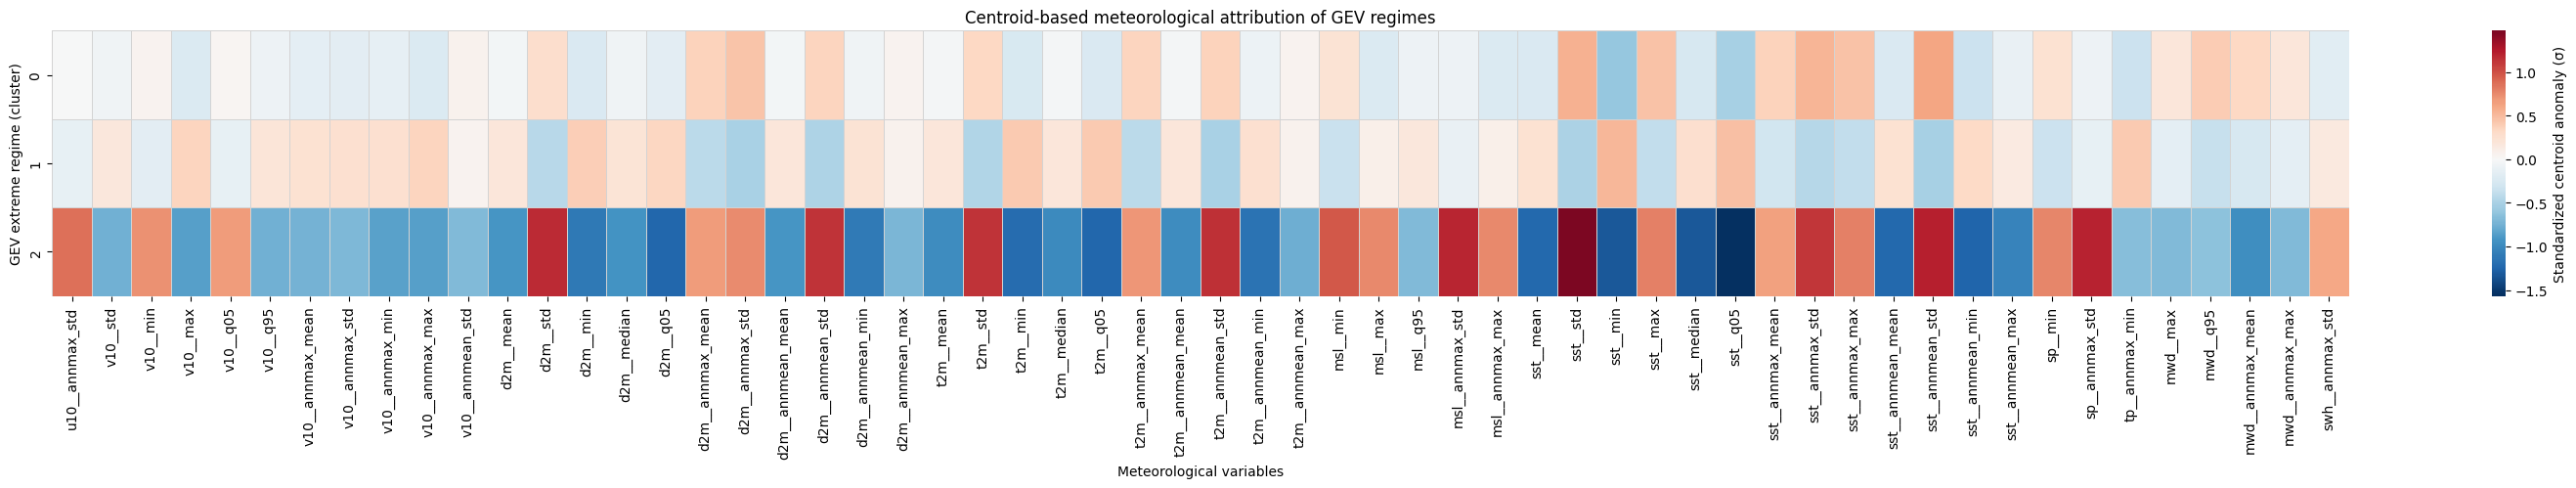

In [8]:
centroid_fingerprint = centroids_std.copy()

# Optional: drop weak signals
centroid_fingerprint = centroid_fingerprint.loc[
    :, centroid_fingerprint.abs().max() > 0.6
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(0.45*centroid_fingerprint.shape[1] + 4,
                    0.7*centroid_fingerprint.shape[0] + 3))

sns.heatmap(
    centroid_fingerprint,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.ylabel("GEV extreme regime (cluster)")
plt.xlabel("Meteorological variables")
plt.title("Centroid-based meteorological attribution of GEV regimes")
plt.tight_layout()
plt.show()



In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

met_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Xs = met_pre.fit_transform(X)


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
sil = {}

for k in k_range:
    km_met = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_met = km_met.fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels_met)

best_k_met = max(sil, key=sil.get)
km_met = KMeans(n_clusters=best_k_met, random_state=0, n_init="auto")
met_cluster = km_met.fit_predict(Xs)

model_df = model_df.copy()
model_df["met_cluster"] = met_cluster

print(model_df["met_cluster"].value_counts())


met_cluster
8    56
2    41
6    32
4    31
7    28
1    28
0    22
3    14
5    14
9    13
Name: count, dtype: int64


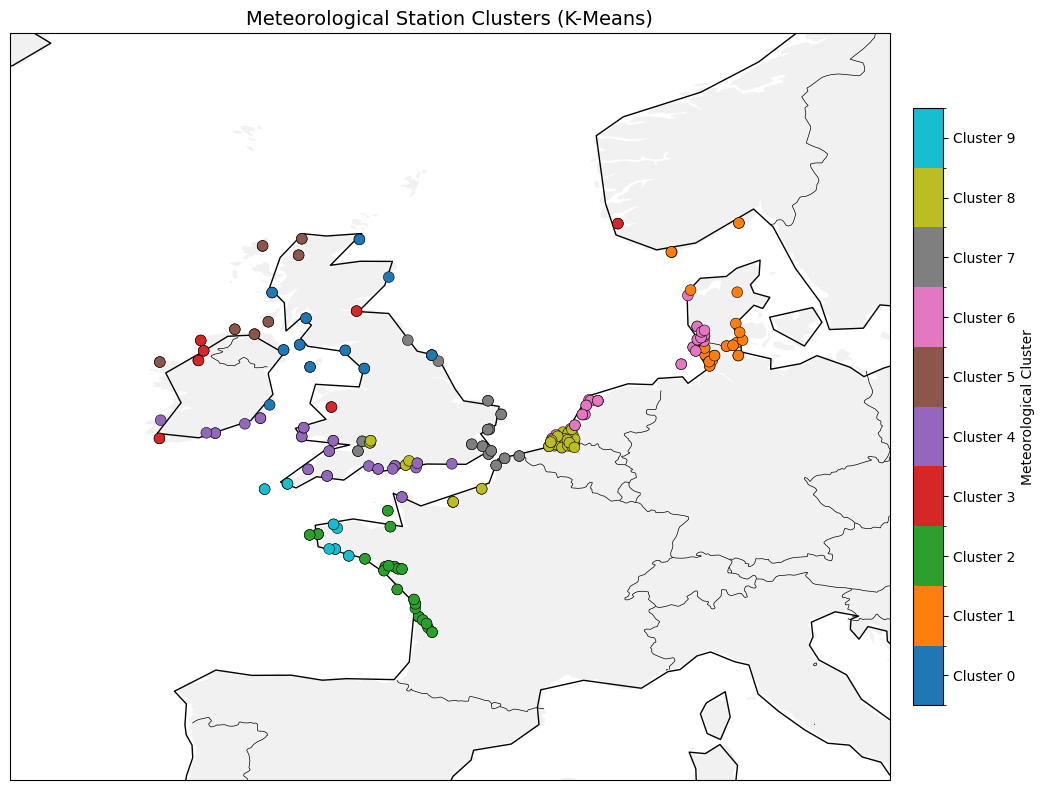

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# -----------------------------
# Prepare discrete colormap
# -----------------------------
clusters = np.sort(model_df["met_cluster"].unique())
n_clusters = len(clusters)

# Use a base categorical colormap and discretize it
base_cmap = plt.get_cmap("tab10")  # good for discrete categories
colors = base_cmap(range(n_clusters))
cmap = ListedColormap(colors)

bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -----------------------------
# Create Cartopy map
# -----------------------------
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()  # or restrict extent if desired
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)

# -----------------------------
# Scatter plot of stations
# -----------------------------
sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["met_cluster"],
    cmap=cmap,
    norm=norm,
    s=60,
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# -----------------------------
# Discrete colorbar
# -----------------------------
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    shrink=0.8,
    ticks=clusters
)
cbar.set_label("Meteorological Cluster")
cbar.set_ticks(clusters)
cbar.set_ticklabels([f"Cluster {i}" for i in clusters])

ax.set_title("Meteorological Station Clusters (K-Means)", fontsize=14)
ax.set_extent([-15,15,40,65])

plt.tight_layout()
plt.show()


In [60]:
bath_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/results/bath_clusters.csv")

In [64]:
bath_df.columns

Index(['Unnamed: 0', 'latitude', 'longitude', 'tile_0.1', 'extent_0.1',
       'tile_0.25', 'extent_0.25', 'tile_1', 'extent_1', 'slope_deg_0.1',
       'roughness_std_0.1', 'relief_p2p_0.1', 'mean_bathy_0.1',
       'slope_deg_0.25', 'roughness_std_0.25', 'relief_p2p_0.25',
       'mean_bathy_0.25', 'slope_deg_1', 'roughness_std_1', 'relief_p2p_1',
       'mean_bathy_1', 'bath_cluster'],
      dtype='object')

In [61]:
centroids_met_std = pd.DataFrame(
    km_met.cluster_centers_,
    columns=X.columns
)


In [62]:
# Recover scaler and imputer from the pipeline
imputer = met_pre.named_steps["imputer"]
scaler  = met_pre.named_steps["scaler"]

# KMeans centers are in standardized space; invert scaling
centroids_met_imputed = scaler.inverse_transform(km_met.cluster_centers_)  # imputed space
centroids_met_phys = pd.DataFrame(centroids_met_imputed, columns=X.columns)

display(centroids_met_phys.head())


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
0,1.493893,4.936673,-17.759583,22.267737,1.627704,-6.766836,9.405391,17.233136,1.805289,13.717512,...,0.230561,2.082058,4.358663,0.603008,3.195276,6.145064,0.878576,0.059422,0.726083,1.044762
1,1.253516,4.435655,-14.537572,20.479311,1.575985,-6.129123,8.099815,14.662564,1.813666,11.615308,...,0.229207,1.860549,3.936022,0.529310,2.805974,5.303459,0.782348,0.052201,0.649679,0.933687
2,1.143746,4.853881,-15.669377,24.305782,1.087590,-6.441626,9.332333,18.093330,1.844395,14.454755,...,0.243876,1.642288,3.012119,0.246531,2.431465,3.703932,0.739673,0.049666,0.620675,0.864508
3,1.168816,3.784060,-13.401906,19.669264,1.139278,-4.972217,7.403560,14.716230,1.670735,11.259785,...,0.344145,2.306996,4.601243,0.671527,3.129822,6.598688,1.036583,0.080707,0.839456,1.228106
4,1.730227,5.123645,-16.983379,22.892736,2.108000,-6.926058,9.682780,17.139942,1.622060,13.857069,...,0.303014,2.490214,5.269758,0.789975,3.747316,7.819257,1.074165,0.076811,0.892346,1.247692


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- inputs assumed ---
# model_df: columns include ["met_cluster", "cluster"] and aligns row-wise with X
# X: meteorological features DataFrame, shape (n_samples, n_features)

# 1) Standardize meteorological features for fair distances
scaler = StandardScaler()
Z = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

# 2) Meteorological cluster centroids in standardized space
met_centroids = Z.join(model_df["met_cluster"]).groupby("met_cluster").mean()

# 3) GEV cluster means expressed in meteorological feature space (standardized)
gev_means_in_met_space = Z.join(model_df["cluster"]).groupby("cluster").mean()


In [15]:
from scipy.spatial.distance import cdist

# Ensure consistent column order
gev_mat = gev_means_in_met_space[met_centroids.columns].to_numpy()
met_mat = met_centroids.to_numpy()

dist_matrix = pd.DataFrame(
    cdist(gev_mat, met_mat, metric="euclidean"),
    index=gev_means_in_met_space.index,      # GEV cluster labels
    columns=met_centroids.index              # met_cluster labels
)

# For each GEV regime, find closest meteorological centroid
closest_met = dist_matrix.idxmin(axis=1)
closest_dist = dist_matrix.min(axis=1)

gev_to_met_summary = pd.DataFrame({
    "closest_met_cluster": closest_met,
    "dist_to_closest_met_centroid": closest_dist
}).sort_index()

print(gev_to_met_summary.head())


         closest_met_cluster  dist_to_closest_met_centroid
cluster                                                   
0                          7                      5.811357
1                          4                      5.256482
2                          6                      7.231567


In [23]:
# Drop features (columns) that contain at least one NaN
X_clean = X.dropna(axis=1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Z = pd.DataFrame(
    scaler.fit_transform(X_clean),
    index=X_clean.index,
    columns=X_clean.columns
)
met_centroids = Z.join(model_df["met_cluster"]).groupby("met_cluster").mean()
gev_means_in_met_space = Z.join(model_df["cluster"]).groupby("cluster").mean()

from scipy.spatial.distance import cdist

gev_mat = gev_means_in_met_space[met_centroids.columns].to_numpy()
met_mat = met_centroids.to_numpy()

dist_matrix = pd.DataFrame(
    cdist(gev_mat, met_mat, metric="euclidean"),
    index=gev_means_in_met_space.index,
    columns=met_centroids.index
)

closest_met = dist_matrix.idxmin(axis=1)
closest_dist = dist_matrix.min(axis=1)

gev_to_met_summary = pd.DataFrame({
    "closest_met_cluster": closest_met,
    "dist_to_closest_met_centroid": closest_dist
}).sort_index()

print(gev_to_met_summary)


         closest_met_cluster  dist_to_closest_met_centroid
cluster                                                   
0                          7                      3.283098
1                          4                      4.041208
2                          1                      4.202514


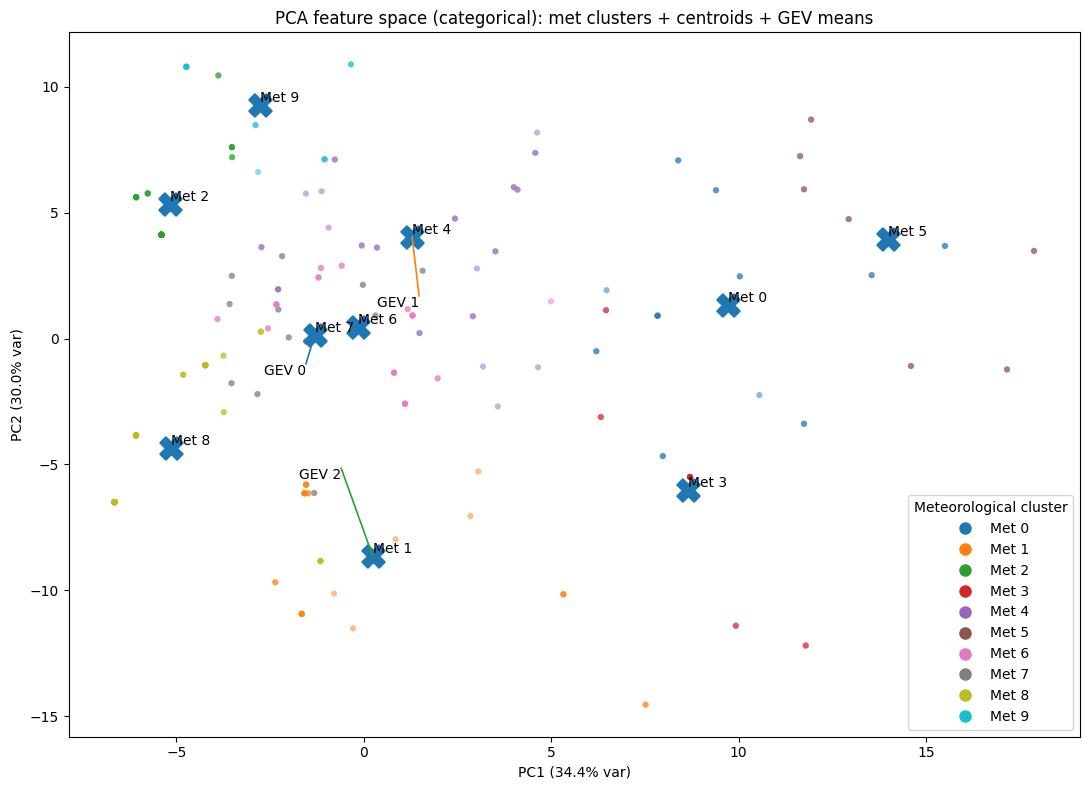

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.decomposition import PCA

# PCA on standardized features Z (no NaNs)
pca = PCA(n_components=2, random_state=0)
Z_2 = pca.fit_transform(Z.to_numpy())

# Project centroids and GEV means
met_2 = pca.transform(met_centroids[Z.columns].to_numpy())
gev_2 = pca.transform(gev_means_in_met_space[Z.columns].to_numpy())

# -----------------------------
# Discrete colormap for met_cluster
# -----------------------------
clusters = np.sort(model_df["met_cluster"].unique())
n_clusters = len(clusters)

base = plt.get_cmap("tab10") if n_clusters <= 10 else plt.get_cmap("tab20")
colors = base(range(n_clusters))
cmap = ListedColormap(colors)

# Map actual cluster labels -> 0..n-1 to ensure clean binning even if labels aren't consecutive
label_to_code = {lab: i for i, lab in enumerate(clusters)}
codes = model_df["met_cluster"].map(label_to_code).to_numpy()

bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 8))

sc = ax.scatter(
    Z_2[:, 0], Z_2[:, 1],
    c=codes,
    cmap=cmap,
    norm=norm,
    s=20,
    alpha=0.5,
    edgecolors="none"
)

# Meteorological centroids (X)
ax.scatter(met_2[:, 0], met_2[:, 1], s=260, marker="X", linewidths=1.5)

# GEV regime means (open circles)
ax.scatter(gev_2[:, 0], gev_2[:, 1], s=200, marker="o", facecolors="none", linewidths=2)

# Labels
for i, mc in enumerate(met_centroids.index):
    ax.text(met_2[i, 0], met_2[i, 1], f"Met {mc}", fontsize=10, ha="left", va="bottom")

for i, gc in enumerate(gev_means_in_met_space.index):
    ax.text(gev_2[i, 0], gev_2[i, 1], f"GEV {gc}", fontsize=10, ha="right", va="top")

# Optional: lines from GEV mean to closest met centroid
met_index_to_pos = {m: j for j, m in enumerate(met_centroids.index)}
for i, gc in enumerate(gev_means_in_met_space.index):
    m = gev_to_met_summary.loc[gc, "closest_met_cluster"]
    j = met_index_to_pos[m]
    ax.plot([gev_2[i, 0], met_2[j, 0]], [gev_2[i, 1], met_2[j, 1]], linewidth=1.2)

ax.set_title("PCA feature space (categorical): met clusters + centroids + GEV means")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")

# -----------------------------
# Discrete legend (recommended over colorbar)
# -----------------------------
handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=cmap(i), markersize=8, label=f"Met {lab}")
    for i, lab in enumerate(clusters)
]
ax.legend(handles=handles, title="Meteorological cluster", loc="best", frameon=True)

plt.tight_layout()
plt.show()



In [27]:
met_means = met_centroids.copy()   # already standardized
# Total variance of each feature
total_var = Z.var()

# Within-cluster variance
within_var = (
    Z.join(model_df["met_cluster"])
     .groupby("met_cluster")
     .var()
     .mean(axis=0)
)

# Between-cluster variance fraction (like 1 - WSS/TSS)
between_frac = 1 - (within_var / total_var)

met_feature_importance = pd.DataFrame({
    "total_var": total_var,
    "within_var": within_var,
    "between_cluster_fraction": between_frac
}).sort_values("between_cluster_fraction", ascending=False)

def top_extremes(df, k=5):
    out = {}
    for idx in df.index:
        s = df.loc[idx].sort_values(key=np.abs, ascending=False)
        out[idx] = s.head(k)
    return out

top_met_extremes = top_extremes(met_means, k=6)

# Example printout
for k, v in top_met_extremes.items():
    print("\nMeteorological cluster", k)
    print(v)




Meteorological cluster 0
d2m__annmax_min    -1.781473
d2m__q95           -1.768561
t2m__q95           -1.679463
d2m__annmax_mean   -1.662906
v10__annmean_max    1.653210
msl__annmax_min    -1.646164
Name: 0, dtype: float64

Meteorological cluster 1
d2m__q05           -1.947662
d2m__annmean_min   -1.827493
sp__annmax_std      1.798703
t2m__q05           -1.795885
msl__annmax_std     1.791030
d2m__std            1.724343
Name: 1, dtype: float64

Meteorological cluster 2
v10__median         -1.666644
v10__annmean_min    -1.590854
t2m__mean            1.382600
t2m__annmean_mean    1.382285
t2m__annmean_max     1.379176
t2m__median          1.372814
Name: 2, dtype: float64

Meteorological cluster 3
sp__q95            -2.738075
sp__annmax_mean    -2.698254
sp__annmean_min    -2.615444
sp__median         -2.609998
sp__annmean_mean   -2.609748
sp__mean           -2.609245
Name: 3, dtype: float64

Meteorological cluster 4
msl__q95             1.295716
u10__median          1.109549
d2m__min    

In [28]:
gev_extremes = gev_means_in_met_space.copy()
top_gev_extremes = top_extremes(gev_extremes, k=6)

for k, v in top_gev_extremes.items():
    print("\nGEV cluster", k)
    print(v)



GEV cluster 0
d2m__annmax_std     0.440259
d2m__annmax_max     0.424771
d2m__max            0.424771
t2m__max            0.368061
t2m__annmax_max     0.368061
t2m__annmean_std    0.364709
Name: 0, dtype: float64

GEV cluster 1
d2m__annmax_std    -0.509044
t2m__annmean_std   -0.504913
d2m__annmean_std   -0.484031
t2m__std           -0.466941
d2m__annmax_max    -0.460155
d2m__max           -0.460155
Name: 1, dtype: float64

GEV cluster 2
t2m__q05          -1.245686
d2m__q05          -1.238551
sp__annmax_std     1.208300
t2m__min          -1.205332
msl__annmax_std    1.192537
d2m__std           1.166456
Name: 2, dtype: float64


In [30]:
gev_vs_met = {}

for g in gev_means_in_met_space.index:
    m = gev_to_met_summary.loc[g, "closest_met_cluster"]
    diff = gev_means_in_met_space.loc[g] - met_centroids.loc[m]
    diff = diff.sort_values(key=np.abs, ascending=False)
    gev_vs_met[g] = diff
for g, d in gev_vs_met.items():
    print("\nGEV", g, "minus Met", gev_to_met_summary.loc[g, "closest_met_cluster"])
    print(d.head(6))



GEV 0 minus Met 7
u10__annmax_std     0.923671
tp__q95             0.686407
tp__annmean_std     0.665563
tp__mean            0.642359
tp__annmean_mean    0.642018
d2m__annmax_max     0.612218
dtype: float64

GEV 1 minus Met 4
u10__median         -1.149874
msl__q95            -1.121730
u10__annmean_min    -1.108357
u10__mean           -1.024967
u10__annmean_mean   -1.021072
msl__annmax_min     -0.795010
dtype: float64

GEV 2 minus Met 1
u10__annmean_min    0.804297
msl__max           -0.783396
msl__annmax_max    -0.783396
d2m__annmean_min    0.728355
u10__annmax_std     0.718866
d2m__q05            0.709112
dtype: float64


In [32]:
within_var_gev = (
    Z.join(model_df["cluster"])
     .groupby("cluster")
     .var()
     .mean(axis=0)
)

between_frac_gev = 1 - (within_var_gev / total_var)

gev_feature_importance = pd.DataFrame({
    "between_cluster_fraction": between_frac_gev
}).sort_values("between_cluster_fraction", ascending=False)

print(gev_feature_importance.head(10))


                  between_cluster_fraction
t2m__std                          0.387380
t2m__annmean_std                  0.383575
d2m__annmax_max                   0.378985
d2m__max                          0.378985
d2m__annmax_std                   0.362946
t2m__q05                          0.358450
d2m__annmean_std                  0.351340
d2m__annmax_mean                  0.338538
t2m__min                          0.320387
t2m__q95                          0.311635


In [33]:
attrib_rows = []

for g in gev_means_in_met_space.index:
    m = gev_to_met_summary.loc[g, "closest_met_cluster"]
    d = gev_means_in_met_space.loc[g]
    top = d.abs().sort_values(ascending=False).head(5).index
    
    for f in top:
        attrib_rows.append({
            "GEV_cluster": g,
            "matched_met_cluster": m,
            "feature": f,
            "GEV_z": gev_means_in_met_space.loc[g, f],
            "met_centroid_z": met_centroids.loc[m, f],
            "GEV_minus_met": gev_means_in_met_space.loc[g, f] - met_centroids.loc[m, f],
            "met_between_frac": met_feature_importance.loc[f, "between_cluster_fraction"],
            "gev_between_frac": gev_feature_importance.loc[f, "between_cluster_fraction"]
        })

attrib_table = pd.DataFrame(attrib_rows)
print(attrib_table.head(10))


   GEV_cluster  matched_met_cluster           feature     GEV_z  \
0            0                    7   d2m__annmax_std  0.440259   
1            0                    7   d2m__annmax_max  0.424771   
2            0                    7          d2m__max  0.424771   
3            0                    7          t2m__max  0.368061   
4            0                    7   t2m__annmax_max  0.368061   
5            1                    4   d2m__annmax_std -0.509044   
6            1                    4  t2m__annmean_std -0.504913   
7            1                    4  d2m__annmean_std -0.484031   
8            1                    4          t2m__std -0.466941   
9            1                    4   d2m__annmax_max -0.460155   

   met_centroid_z  GEV_minus_met  met_between_frac  gev_between_frac  
0        0.123880       0.316379          0.561989          0.362946  
1       -0.187447       0.612218          0.743736          0.378985  
2       -0.187447       0.612218          0.74373

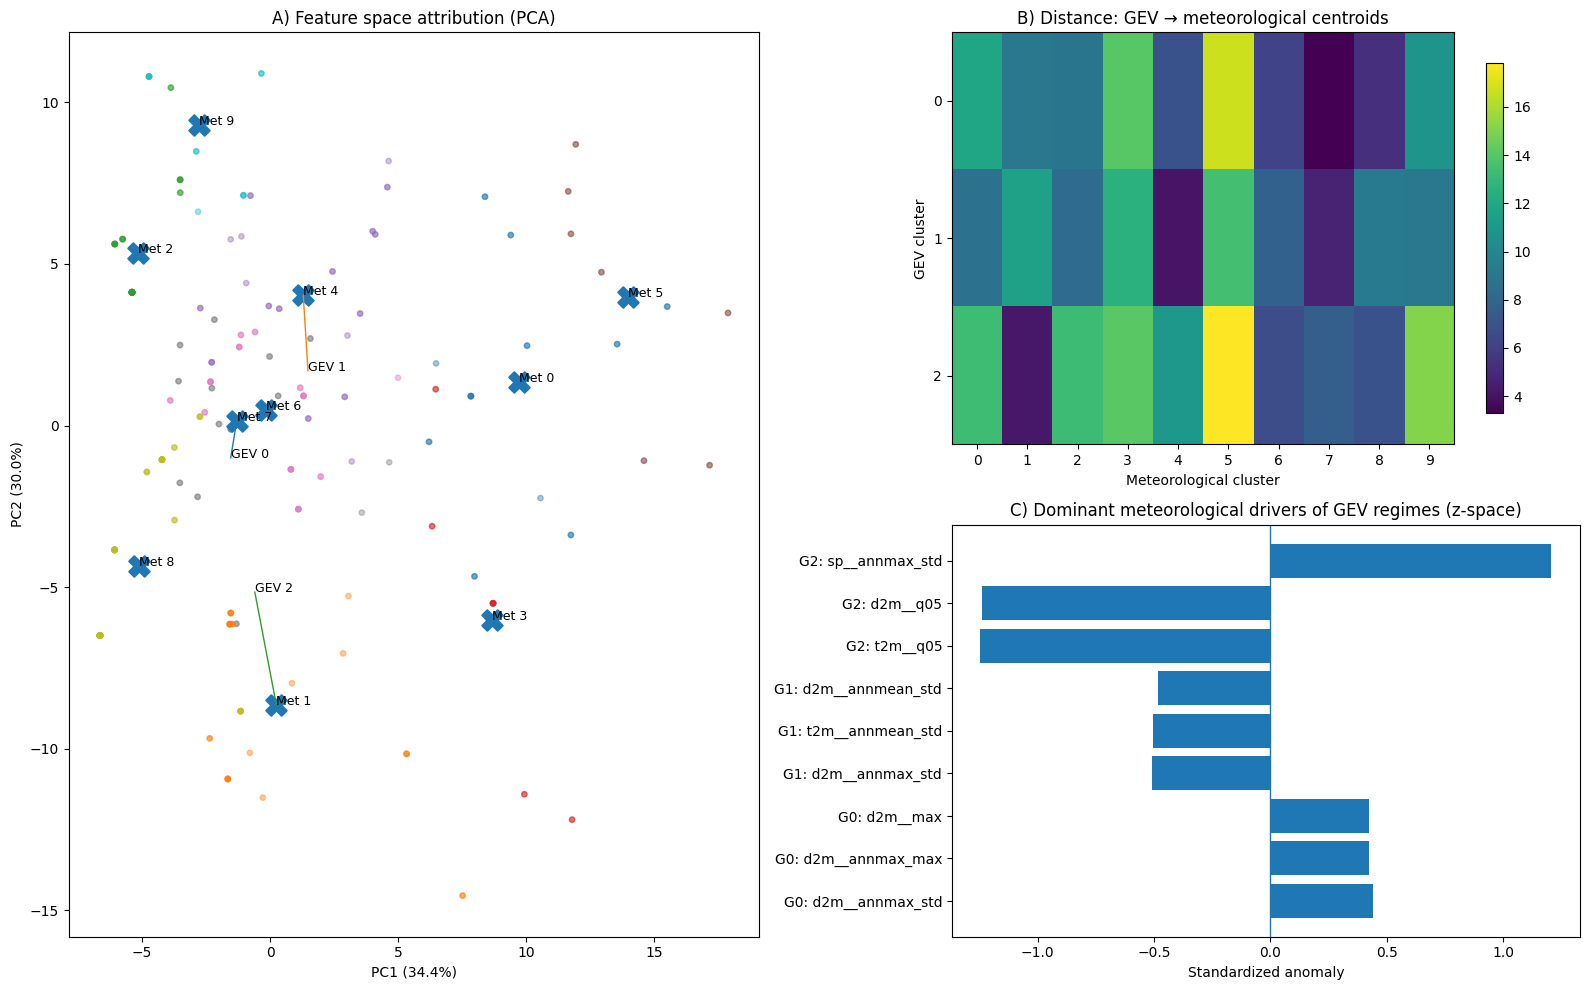

In [38]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, BoundaryNorm

pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(Z.to_numpy())

met2 = pca.transform(met_centroids[Z.columns].to_numpy())
gev2 = pca.transform(gev_means_in_met_space[Z.columns].to_numpy())

met_labels = np.sort(model_df["met_cluster"].unique())
lab2code = {lab:i for i,lab in enumerate(met_labels)}
codes = model_df["met_cluster"].map(lab2code)

cmap = ListedColormap(plt.get_cmap("tab10")(range(len(met_labels))))
norm = BoundaryNorm(np.arange(-0.5, len(met_labels)+0.5, 1), cmap.N)

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1])

# -----------------------
# Panel A — PCA space
# -----------------------
ax0 = fig.add_subplot(gs[:, 0])

sc = ax0.scatter(Z2[:,0], Z2[:,1], c=codes, cmap=cmap, norm=norm, s=15, alpha=0.4)
ax0.scatter(met2[:,0], met2[:,1], marker="X", s=220, linewidths=1.4)
ax0.scatter(gev2[:,0], gev2[:,1], facecolors="none", s=200, linewidths=2)

for i,m in enumerate(met_centroids.index):
    ax0.text(met2[i,0], met2[i,1], f"Met {m}", fontsize=9)

for i,g in enumerate(gev_means_in_met_space.index):
    ax0.text(gev2[i,0], gev2[i,1], f"GEV {g}", fontsize=9)

for i,g in enumerate(gev_means_in_met_space.index):
    m = gev_to_met_summary.loc[g,"closest_met_cluster"]
    j = list(met_centroids.index).index(m)
    ax0.plot([gev2[i,0], met2[j,0]], [gev2[i,1], met2[j,1]], linewidth=1)

ax0.set_title("A) Feature space attribution (PCA)")
ax0.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax0.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# -----------------------
# Panel B — distance heatmap
# -----------------------
ax1 = fig.add_subplot(gs[0,1])
im = ax1.imshow(dist_matrix.values, aspect="auto")
ax1.set_title("B) Distance: GEV → meteorological centroids")
ax1.set_xlabel("Meteorological cluster")
ax1.set_ylabel("GEV cluster")
ax1.set_xticks(range(len(dist_matrix.columns)))
ax1.set_xticklabels(dist_matrix.columns)
ax1.set_yticks(range(len(dist_matrix.index)))
ax1.set_yticklabels(dist_matrix.index)
plt.colorbar(im, ax=ax1, shrink=0.85)

# -----------------------
# Panel C — top drivers (example: one bar block per GEV)
# -----------------------
ax2 = fig.add_subplot(gs[1,1])

bars = []
labels = []
offset = 0

for g in gev_means_in_met_space.index:
    top = gev_means_in_met_space.loc[g].abs().sort_values(ascending=False).head(3)
    for f in top.index:
        bars.append(gev_means_in_met_space.loc[g, f])
        labels.append(f"G{g}: {f}")
    offset += 1

ax2.barh(labels, bars)
ax2.axvline(0, linewidth=1)
ax2.set_title("C) Dominant meteorological drivers of GEV regimes (z-space)")
ax2.set_xlabel("Standardized anomaly")

plt.tight_layout()
plt.show()


In [39]:
q95_features = [c for c in Z.columns if "q95" in c.lower()]

Z_q95 = Z[q95_features]

met_q95 = Z_q95.join(model_df["met_cluster"]).groupby("met_cluster").mean()
gev_q95 = Z_q95.join(model_df["cluster"]).groupby("cluster").mean()

# Build attribution-aligned table
rows = []
index = []

for g in gev_q95.index:
    m = gev_to_met_summary.loc[g, "closest_met_cluster"]
    diff = gev_q95.loc[g] - met_q95.loc[m]
    rows.append(
        pd.concat([
            gev_q95.loc[g].add_prefix("GEV_"),
            met_q95.loc[m].add_prefix("MET_"),
            diff.add_prefix("DIFF_")
        ])
    )
    index.append(g)

q95_table = pd.DataFrame(rows, index=index)


In [46]:
GEV_clusters

,station,lat,lon,n_blocks,gev_c,gev_loc,gev_scale,ks_stat,ks_pvalue,kuiper,r2_cdf,cluster
0,1,48.383000,-4.495000,399,0.019139,0.396665,0.154269,0.024895,9.604563e-01,0.049499,0.998840,1
1,10,45.568480,-1.061555,237,0.008840,0.396950,0.213067,0.039537,8.380715e-01,0.076210,0.996165,1
2,102,50.102000,-5.542000,377,0.091521,0.382410,0.133945,0.028702,9.063368e-01,0.053232,0.998736,1
3,103,50.103000,-5.542750,448,0.182677,0.416630,0.338177,0.198556,5.918320e-16,0.348877,0.833575,0
4,104,50.099998,-5.533330,208,0.207246,0.355758,0.397802,0.227428,6.154688e-10,0.426214,0.779586,0
...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,49.930000,1.085000,354,0.134247,0.648707,0.249021,0.032957,8.242212e-01,0.060356,0.997792,0
275,94,49.481602,0.105600,334,-0.071086,0.606402,0.217723,0.049914,3.641023e-01,0.082405,0.994583,1
276,95,49.651299,-1.635500,307,0.041510,0.421703,0.156389,0.046830,4.964226e-01,0.092796,0.994417,1
277,97,49.183300,-2.116700,194,0.001364,0.500910,0.167137,0.047496,7.555074e-01,0.083306,0.995876,1


In [52]:
# Example expected structure:
# gev_params.index = GEV cluster labels
# gev_params columns include ["loc","scale","shape"] (or ["mu","sigma","xi"])

gev_params = GEV_clusters.copy()
gev_params = gev_params.rename(columns={"gev_loc":"loc", "gev_scale":"scale", "gev_c":"shape"})
gev_params = gev_params[["loc","scale","shape"]]

gev_param_table = gev_params.join(gev_to_met_summary["closest_met_cluster"])

# Optional: reorder columns for display
gev_param_table = gev_param_table[["closest_met_cluster", "loc", "scale", "shape"]]

print(gev_param_table)

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

# -----------------------------
# 1) GEV parameter means per GEV regime
# -----------------------------
gev_param_cols = ["loc", "scale", "shape"]   # rename if yours differ

# gev_param_df must align with model_df rows (same index)
gev_regime_means = (
    model_df[["cluster"]]
    .join(gev_params[gev_param_cols])
    .groupby("cluster")
    .mean()
    .add_prefix("GEV_")
)

# -----------------------------
# 2) Meteorological q95 variable means per meteorological regime
# -----------------------------
q95_cols = [c for c in X.columns if "q95" in c.lower()]

met_regime_means = (
    model_df[["met_cluster"]]
    .join(X[q95_cols])                 # use X (raw) or Z (standardized); see note below
    .groupby("met_cluster")
    .mean()
    .add_prefix("MET_")
)

# -----------------------------
# 3) Attach matched meteorological regime to each GEV regime
# -----------------------------
match = gev_to_met_summary[["closest_met_cluster"]].copy()
match.index.name = "cluster"

# bring met means onto each GEV cluster via its matched met_cluster
met_for_gev = met_regime_means.loc[match["closest_met_cluster"].values].copy()
met_for_gev.index = match.index  # set rows = GEV clusters

# -----------------------------
# 4) Final table
# -----------------------------
q95_table = gev_regime_means.join(met_for_gev)
q95_table.insert(0, "matched_met_cluster", match["closest_met_cluster"])

print(q95_table)


     closest_met_cluster       loc     scale     shape
0                    7.0  0.396665  0.154269  0.019139
1                    4.0  0.396950  0.213067  0.008840
2                    1.0  0.382410  0.133945  0.091521
3                    NaN  0.416630  0.338177  0.182677
4                    NaN  0.355758  0.397802  0.207246
..                   ...       ...       ...       ...
274                  NaN  0.648707  0.249021  0.134247
275                  NaN  0.606402  0.217723 -0.071086
276                  NaN  0.421703  0.156389  0.041510
277                  NaN  0.500910  0.167137  0.001364
278                  NaN  0.608047  0.222756 -0.149146

[279 rows x 4 columns]
         matched_met_cluster   GEV_loc  GEV_scale  GEV_shape  MET_u10__q95  \
cluster                                                                      
0                          7  0.856617   0.361995   0.167322      8.751677   
1                          4  0.450909   0.185973   0.029939      9.682780   
2   

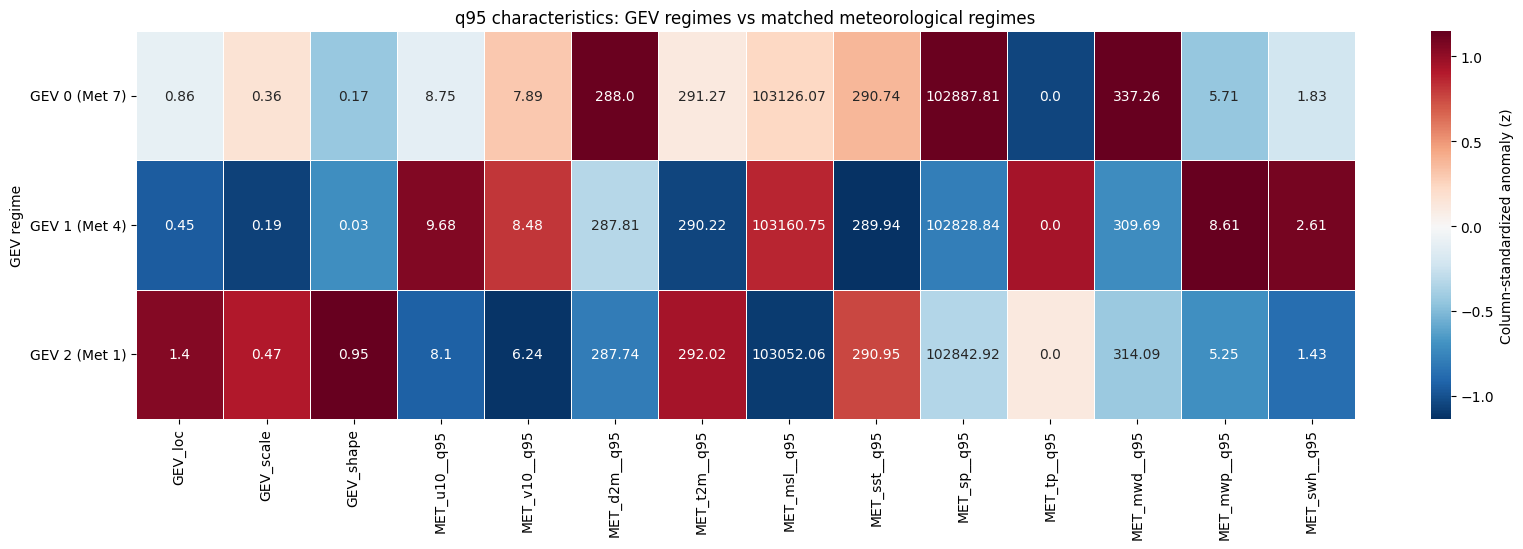

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_cols = [c for c in q95_table.columns if c.startswith("GEV_") or c.startswith("MET_")]

# -----------------------------
# Standardize each column for colouring ONLY
# -----------------------------
heat_vals = (q95_table[plot_cols] - q95_table[plot_cols].mean()) / q95_table[plot_cols].std()

# True values for annotation
annot_vals = q95_table[plot_cols].round(2)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(1.2*len(plot_cols), 1.2*len(q95_table) + 2))

ax = sns.heatmap(
    heat_vals,
    annot=annot_vals,
    fmt="",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Column-standardized anomaly (z)"}
)

ax.set_title("q95 characteristics: GEV regimes vs matched meteorological regimes")
ax.set_ylabel("GEV regime")
ax.set_xlabel("")

# Optional: include matched met regime in row labels
if "matched_met_cluster" in q95_table.columns:
    yt = [f"GEV {i} (Met {q95_table.loc[i,'matched_met_cluster']})" for i in q95_table.index]
    ax.set_yticklabels(yt, rotation=0)

plt.tight_layout()
plt.show()



In [16]:
# Per-station distance to its assigned meteorological centroid
met_id = model_df["met_cluster"].to_numpy()
centroids_lookup = met_centroids.loc[model_df["met_cluster"]].to_numpy()

station_dist_to_assigned = np.linalg.norm(Z.to_numpy() - centroids_lookup, axis=1)

model_df = model_df.copy()
model_df["dist_to_assigned_met_centroid"] = station_dist_to_assigned

# Summarize by GEV regime
gev_dispersion = model_df.groupby("cluster")["dist_to_assigned_met_centroid"].agg(
    mean_dist="mean",
    median_dist="median",
    n="count"
)

print(gev_dispersion.head())


         mean_dist  median_dist   n
cluster                            
0         5.633524     4.807957  67
1         5.850896     5.518638  76
2         5.652360     5.873538   5


In [89]:
ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")
print(ct)


met_cluster         0         1         2         3         4         5  \
cluster                                                                   
0            0.065574  0.008197  0.065574  0.024590  0.049180  0.016393   
1            0.102941  0.110294  0.242647  0.080882  0.176471  0.088235   
2            0.000000  0.571429  0.000000  0.000000  0.047619  0.000000   

met_cluster         6         7         8         9  
cluster                                              
0            0.221311  0.172131  0.352459  0.024590  
1            0.007353  0.051471  0.066176  0.073529  
2            0.190476  0.000000  0.190476  0.000000  


In [90]:
from scipy.stats import chi2_contingency

ct_counts = pd.crosstab(model_df["cluster"], model_df["met_cluster"])
chi2, p, dof, expected = chi2_contingency(ct_counts)

print("chi2:", chi2, "p-value:", p)


chi2: 169.08709593312676 p-value: 1.370637162936017e-26


In [91]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(model_df["cluster"], model_df["met_cluster"])
print("Mutual information:", mi)


Mutual information: 0.3064172502516693


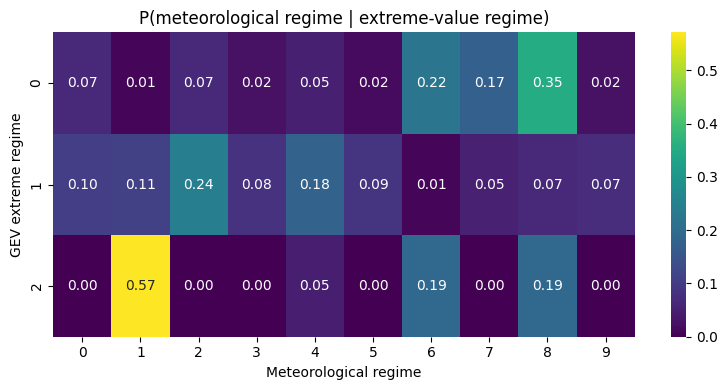

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")

plt.figure(figsize=(8,4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="viridis")

plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("P(meteorological regime | extreme-value regime)")

plt.tight_layout()
plt.show()


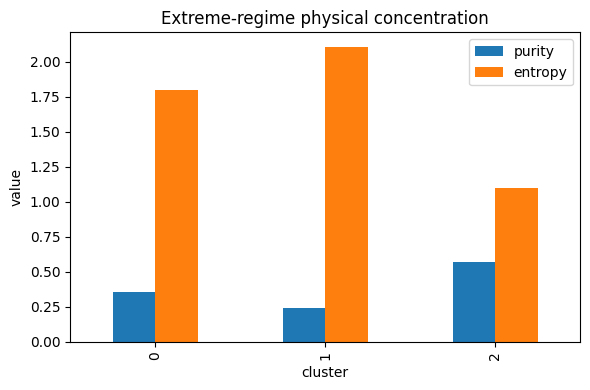

In [93]:
ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")

dominant = ct.idxmax(axis=1)
purity = ct.max(axis=1)
entropy = -(ct * np.log(ct + 1e-12)).sum(axis=1)

summary = pd.DataFrame({
    "dominant_met_regime": dominant,
    "purity": purity,
    "entropy": entropy
})

summary[["purity", "entropy"]].plot(kind="bar", figsize=(6,4))
plt.title("Extreme-regime physical concentration")
plt.ylabel("value")
plt.tight_layout()
plt.show()


Interpretation:

purity → how concentrated the attribution is

entropy → how many meteorological pathways exist

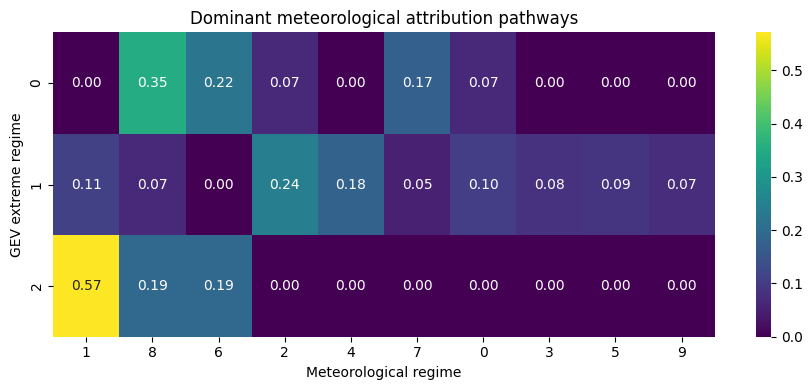

In [94]:
# order columns by overall contribution
order = ct.sum(axis=0).sort_values(ascending=False).index
ct_ord = ct[order]

# zero-out very small probabilities
ct_masked = ct_ord.where(ct_ord > 0.05, 0)

plt.figure(figsize=(9,4))
sns.heatmap(ct_masked, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("Dominant meteorological attribution pathways")
plt.tight_layout()
plt.show()


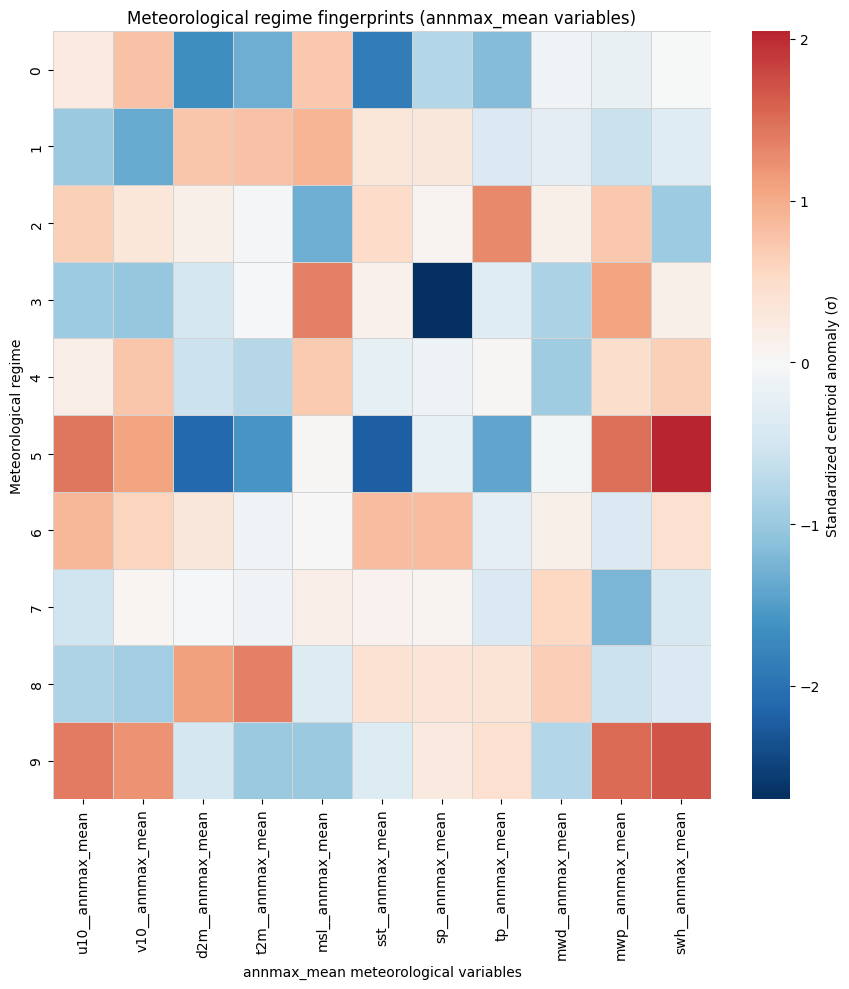

In [95]:
annmax_vars = [c for c in centroids_met_phys.columns if "annmax_mean" in c.lower()]
met_centroids_annmax = centroids_met_phys[annmax_vars].copy()
met_centroids_annmax.index.name = "met_regime"

annmax_std = centroids_met_std[annmax_vars]

# Optional: remove very weak dimensions
annmax_std = annmax_std.loc[:, annmax_std.abs().max(axis=0) > 0.5]

plt.figure(figsize=(0.45*annmax_std.shape[1] + 4,
                    0.7*annmax_std.shape[0] + 3))

sns.heatmap(
    annmax_std,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.xlabel("annmax_mean meteorological variables")
plt.ylabel("Meteorological regime")
plt.title("Meteorological regime fingerprints (annmax_mean variables)")
plt.tight_layout()
plt.show()


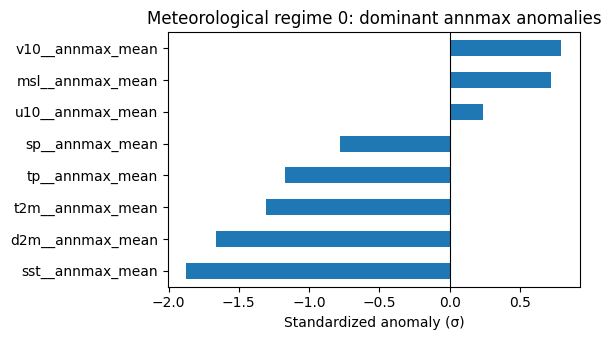

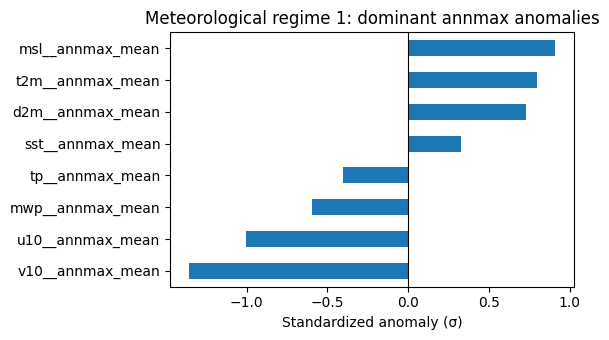

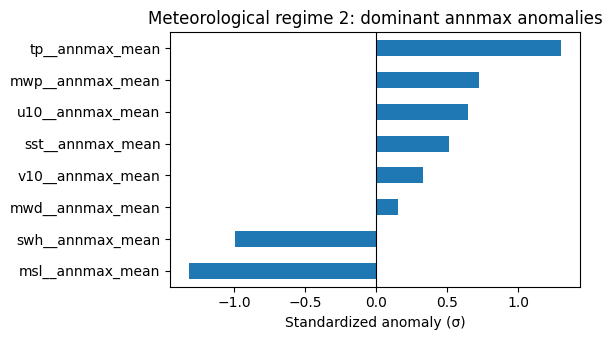

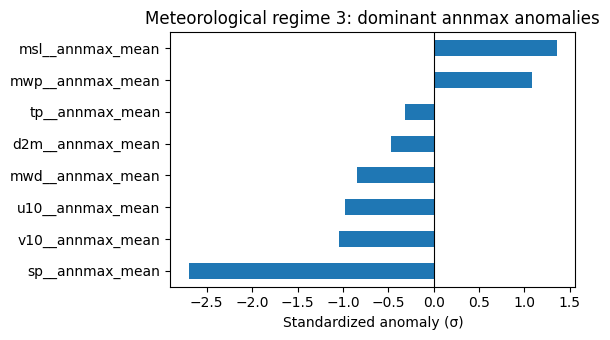

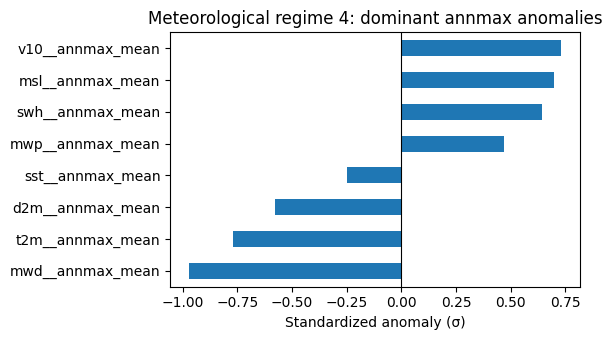

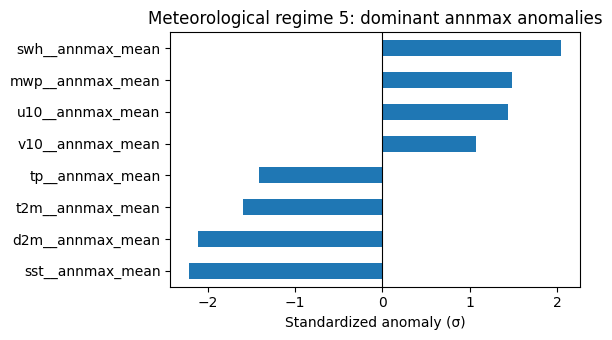

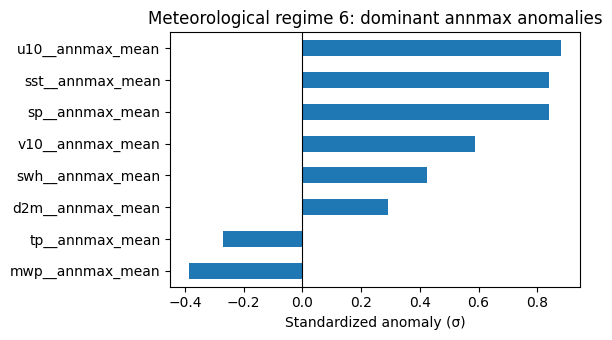

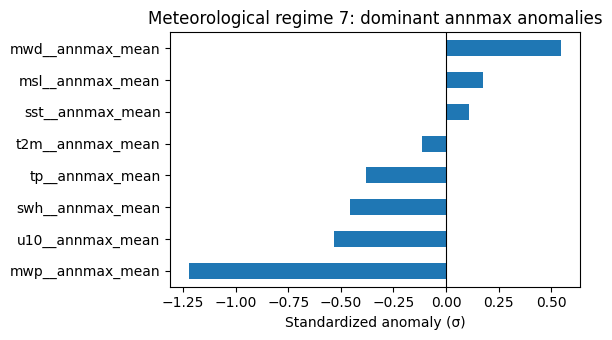

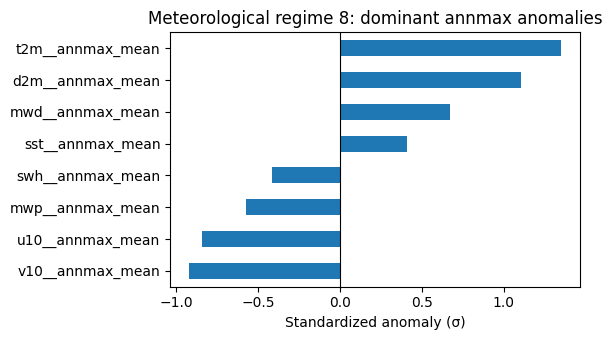

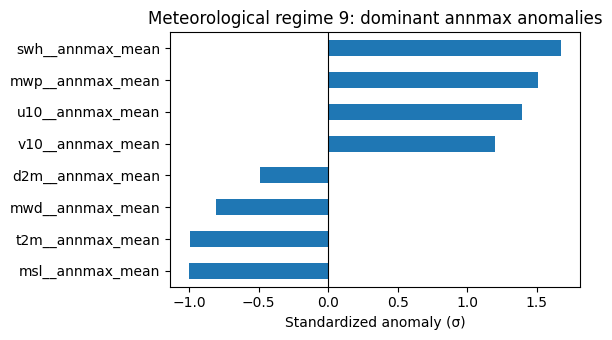

In [96]:
import numpy as np

TOP = 8

for mc in annmax_std.index:
    s = annmax_std.loc[mc].sort_values(key=lambda x: np.abs(x), ascending=False).head(TOP)

    plt.figure(figsize=(6,3.5))
    s.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)

    plt.title(f"Meteorological regime {mc}: dominant annmax anomalies")
    plt.xlabel("Standardized anomaly (σ)")
    plt.tight_layout()
    plt.show()


Dominant meteorological regimes: [1, 2, 8]


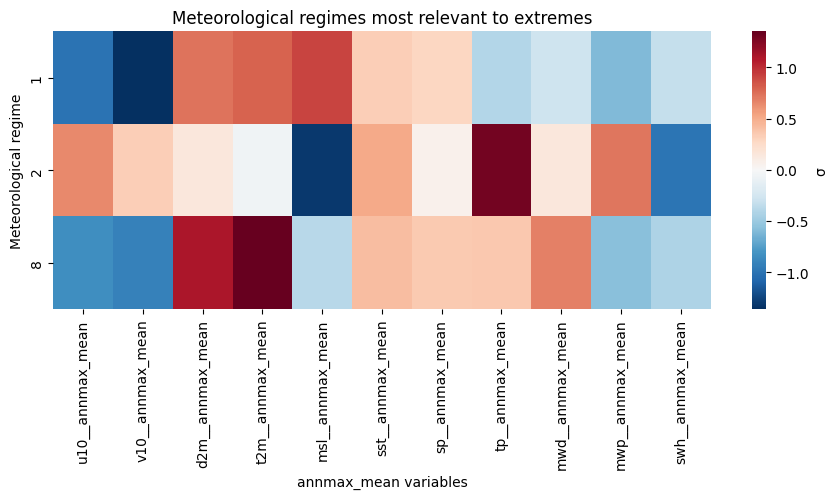

In [97]:
# meteorological regimes that dominate any extreme regime
dominant_mets = set(ct.idxmax(axis=1))
dominant_mets = sorted(dominant_mets)

print("Dominant meteorological regimes:", dominant_mets)

annmax_dom = annmax_std.loc[dominant_mets]

plt.figure(figsize=(0.45*annmax_dom.shape[1] + 4,
                    0.7*annmax_dom.shape[0] + 3))

sns.heatmap(annmax_dom, center=0, cmap="RdBu_r",
            cbar_kws={"label": "σ"})
plt.title("Meteorological regimes most relevant to extremes")
plt.xlabel("annmax_mean variables")
plt.ylabel("Meteorological regime")
plt.tight_layout()
plt.show()


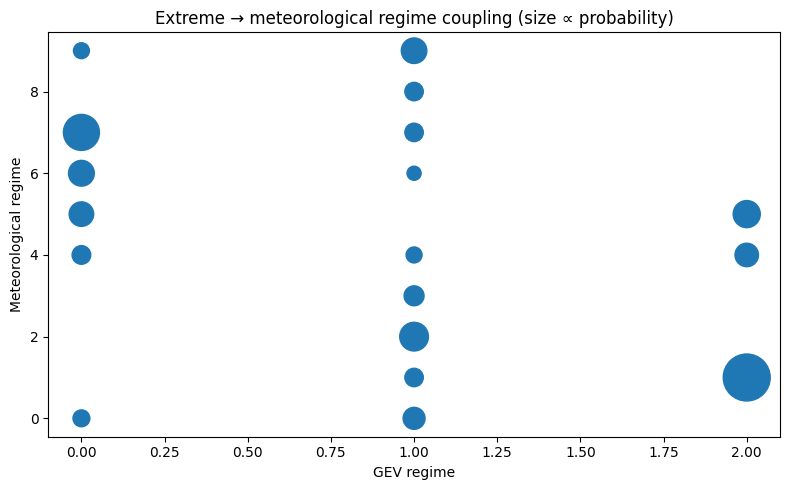

In [77]:
import matplotlib.pyplot as plt

flows = ct.stack().reset_index()
flows.columns = ["gev", "met", "p"]
flows = flows[flows["p"] > 0.05]  # keep only meaningful links

plt.figure(figsize=(8,5))
plt.scatter(flows["gev"], flows["met"], s=flows["p"]*2000)
plt.xlabel("GEV regime")
plt.ylabel("Meteorological regime")
plt.title("Extreme → meteorological regime coupling (size ∝ probability)")
plt.tight_layout()
plt.show()


In [67]:
ct2 = pd.crosstab(model_df["met_cluster"], model_df["cluster"], normalize="index")
print(ct2)


cluster             0         1         2
met_cluster                              
0            0.346154  0.653846  0.000000
1            0.076923  0.461538  0.461538
2            0.147059  0.852941  0.000000
3            0.210526  0.736842  0.052632
4            0.478261  0.391304  0.130435
5            0.791667  0.041667  0.166667
6            0.750000  0.250000  0.000000
7            0.759259  0.222222  0.018519
8            0.142857  0.857143  0.000000
9            0.258065  0.741935  0.000000


In [68]:
# For each meteorological cluster, list the strongest centroid anomalies (standardized)
centroids_met_std = pd.DataFrame(km_met.cluster_centers_, columns=X.columns)
spread = centroids_met_std.abs().max(axis=0)

# For each meteorological cluster, print top defining variables
TOP = 10
for mc in range(best_k_met):
    s = centroids_met_std.loc[mc].sort_values(key=lambda x: abs(x), ascending=False).head(TOP)
    print(f"\nMeteorological cluster {mc} top centroid components:")
    print(s)



Meteorological cluster 0 top centroid components:
sst__q95           -1.820579
sst__annmax_mean   -1.814936
sst__annmax_min    -1.781586
d2m__annmax_min    -1.682370
sst__annmax_max    -1.657649
sst__max           -1.657649
v10__annmean_max    1.656703
t2m__q95           -1.621361
d2m__annmax_mean   -1.616575
d2m__q95           -1.615778
Name: 0, dtype: float64

Meteorological cluster 1 top centroid components:
d2m__q05            -1.965132
d2m__annmean_min    -1.811776
t2m__annmean_min    -1.779794
msl__annmax_std      1.766056
sp__annmax_std       1.751424
t2m__q05            -1.721811
d2m__mean           -1.699212
d2m__annmean_mean   -1.698709
mwd__missing_frac    1.687301
mwp__missing_frac    1.687301
Name: 1, dtype: float64

Meteorological cluster 2 top centroid components:
t2m__q05             1.384273
d2m__annmean_min     1.366773
d2m__median          1.357846
t2m__annmean_min     1.331662
d2m__annmean_mean    1.323122
d2m__mean            1.322582
t2m__mean            1.276803

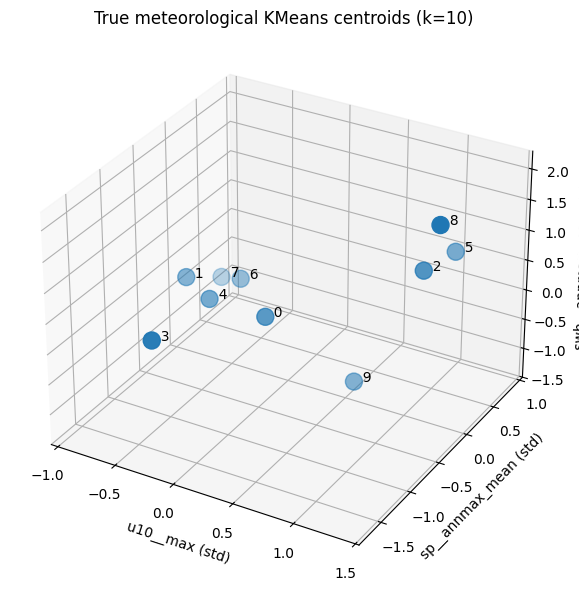

In [70]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.pyplot as plt

vars3 = ["u10__max", "sp__annmax_mean", "swh__annmax_mean"]  # use names that exist in X

C = centroids_met_std[vars3]  # true met centroids in standardized space

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(C[vars3[0]], C[vars3[1]], C[vars3[2]], s=150)

for mc in C.index:
    ax.text(C.loc[mc, vars3[0]], C.loc[mc, vars3[1]], C.loc[mc, vars3[2]], f"  {mc}", fontsize=10)

ax.set_xlabel(vars3[0] + " (std)")
ax.set_ylabel(vars3[1] + " (std)")
ax.set_zlabel(vars3[2] + " (std)")
ax.set_title(f"True meteorological KMeans centroids (k={best_k_met})")

plt.tight_layout()
plt.show()
